In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SAE(nn.Module):
    def __init__(self, d_in, d_hidden, l1_coeff=3e-4):
        super().__init__()
        self.encoder = nn.Linear(d_in, d_hidden, bias=False)
        self.decoder = nn.Linear(d_hidden, d_in, bias=False)
        self.l1_coeff = l1_coeff

        # Tied weights option (recommended for interpretability)
        self.decoder.weight = nn.Parameter(self.encoder.weight.T)

    def forward(self, x):
        # Sparse latent features
        z = F.relu(self.encoder(x))
        # Reconstruction
        x_hat = self.decoder(z)
        return x_hat, z

    def loss(self, x, x_hat, z):
        mse = ((x - x_hat)**2).mean()
        l1 = self.l1_coeff * z.abs().sum(dim=-1).mean()
        return mse + l1


In [ ]:
from tqdm.auto import tqdm

def train_sae(model, data_loader, lr=1e-3, epochs=3, device="cuda"):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(epochs):
        loop = tqdm(data_loader, desc=f"SAE Epoch {epoch+1}/{epochs}", leave=False)

        for (x,) in loop:
            x = x.to(device)
            x_hat, z = model(x)
            loss = model.loss(x, x_hat, z)

            opt.zero_grad()
            loss.backward()
            opt.step()

            loop.set_postfix(loss=f"{loss.item():.4f}")

        print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

    return model


In [ ]:
def train_matryoshka_saes(num_saes, d_in, width, data, batch_size=128):
    saes = []
    residual = data.clone()

    for i in range(num_saes):
        print(f"\n=== Training SAE {i+1}/{num_saes} ===")

        dataset = torch.utils.data.TensorDataset(residual)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

        sae = SAE(d_in, width).cuda()
        sae = train_sae(sae, loader)

        # Compute residual for next SAE
        with torch.no_grad():
            x_hat, _ = sae(residual.cuda())
            residual = (residual.cuda() - x_hat).cpu()

        saes.append(sae)

    return saes


In [ ]:
def combined_dictionary(saes):
    dicts = []
    for sae in saes:
        W = sae.decoder.weight.data.clone()   # feature → direction
        dicts.append(W)
    return torch.cat(dicts, dim=0)


In [ ]:
def get_feature_activations(saes, x):
    zs = []
    for sae in saes:
        _, z = sae(x)
        zs.append(z)
    return torch.cat(zs, dim=-1)


In [ ]:
def reconstruct_with_matryoshka(saes, x):
    x_hat_total = torch.zeros_like(x)
    for sae in saes:
        x_hat, _ = sae(x)
        x_hat_total += x_hat
    return x_hat_total


In [ ]:
def top_activating_tokens(saes, model, tokenizer, prompt_list, feature_id, k=10):
    feature_acts = []
    texts = []

    for text in prompt_list:
        toks = model.to_tokens(text)
        acts = []

        def hook(_, inp, out):
            acts.append(out.detach().cpu())

        model.run_with_hooks(
            toks, fwd_hooks=[("blocks.10.mlp.hook_post", hook)]
        )

        x = torch.cat(acts, dim=0)
        z = get_feature_activations(saes, x)[..., feature_id]
        feature_acts.append(z.max().item())
        texts.append(text)

    top = sorted(zip(feature_acts, texts), reverse=True)[:k]
    return top


In [ ]:
# ============================================================
# Train Matryoshka SAEs on the collected activations
# ============================================================

# Your captured activations are already in:  data
# shape: [N_tokens, d_model]
def extract_activations(sample):
    acts_list = sample["activations"]

    # Concatenate across forward passes
    # Each tensor: [batch, seq, d_model]
    acts = torch.cat(acts_list, dim=1)   # [batch, total_seq, d_model]

    # Flatten batch + sequence
    acts = acts.reshape(-1, acts.shape[-1])

    return acts


import os

from google.colab import drive
drive.mount("/content/drive")
import os
import torch
import pandas as pd

# --------------------------------------------
# Paths (adjust if needed)
# --------------------------------------------
csv_path = "/content/drive/MyDrive/Pythia2.8B_reward_hacking_results.csv"
activation_dir = "/content/drive/MyDrive/SAE_Works_Pythia-2.8B/"

# --------------------------------------------
# Load CSV
# --------------------------------------------
df = pd.read_csv(csv_path)
print(df["reward_hacked"].dtype)
print(df["reward_hacked"].unique())
# Keep only reward-hacking examples
df_hacked = df[df["reward_hacked"] == True]


print(f"Using {len(df_hacked)} reward-hacking sequences")

# --------------------------------------------
# Load corresponding activation files
# --------------------------------------------
activation_tensors = []

for run_id, row in df.iterrows():
    if not row["reward_hacked"]:
        continue

    filename = f"run_{run_id:05d}.pt"
    path = os.path.join(activation_dir, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing activation file: {path}")

    sample = torch.load(path)

    # sample["activations"] is a list of [1, seq, d_model] tensors
    acts_list = sample["activations"]

    # Concatenate across generation steps
    acts = torch.cat(acts_list, dim=1)   # [1, total_seq, d_model]

    # Flatten tokens
    acts = acts.reshape(-1, acts.shape[-1]).float()

    activation_tensors.append(acts)

print(f"Loaded {len(activation_tensors)} hacked activation files")




# --------------------------------------------
# Final SAE training tensor

# --------------------------------------------
data = torch.cat(activation_tensors, dim=0)

import pandas as pd

csv_path = "/content/drive/MyDrive/Pythia2.8B_reward_hacking_results.csv"
df = pd.read_csv(csv_path)

num_true = (df["reward_hacked"] == True).sum()
num_total = len(df)

print(f"Reward hacking TRUE: {num_true}")
print(f"Total samples: {num_total}")
print({num_true/num_total})
print(f"Fraction hacked: {num_true / num_total:.3f}")


print("Final SAE training data shape:", data.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
bool
[ True False]
Using 1405 reward-hacking sequences
Loaded 1405 hacked activation files
Reward hacking TRUE: 1405
Total samples: 2985
{np.float64(0.47068676716917923)}
Fraction hacked: 0.471
Final SAE training data shape: torch.Size([177298, 2560])
Activation tensor shape: torch.Size([177298, 2560])


NameError: name 'device' is not defined

In [ ]:
# ---- Hyperparameters ----
NUM_SAES = 4          # how many SAEs in the matryoshka stack
WIDTH = 2048          # hidden dimension for each SAE
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 3
device = "cuda" if torch.cuda.is_available() else "cpu"
d_in = data.shape[-1]
print("Activation tensor shape:", data.shape)
print("Training SAEs on device:", device)

# Matryoshka training loop (slightly upgraded for clarity)
saes = []
residual = data.clone()

for i in range(NUM_SAES):
    print(f"\n============================")
    print(f" TRAINING SAE {i+1}/{NUM_SAES}")
    print(f"============================")

    # Build dataset for this level
    dataset = torch.utils.data.TensorDataset(residual)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Create SAE
    sae = SAE(d_in=d_in, d_hidden=WIDTH).to(device)

    # Train SAE
    opt = torch.optim.AdamW(sae.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        loop = tqdm(loader, desc=f"SAE {i+1} | Epoch {epoch+1}/{EPOCHS}")

        for (x,) in loop:
            x = x.to(device)
            x_hat, z = sae(x)
            loss = sae.loss(x, x_hat, z)

            opt.zero_grad()
            loss.backward()
            opt.step()

            loop.set_postfix(loss=f"{loss.item():.4f}")

        print(f"SAE {i+1} Epoch {epoch+1}: loss = {loss.item():.4f}")

    # Store trained SAE
    saes.append(sae)

    # Compute residual for next SAE
    with torch.no_grad():
        x_hat, _ = sae(residual.to(device))
        residual = (residual.to(device) - x_hat).cpu()

print("\n🎉 Finished training all Matryoshka SAEs!")
print(f"Total SAEs trained: {len(saes)}")


Activation tensor shape: torch.Size([177298, 2560])
Training SAEs on device: cuda

 TRAINING SAE 1/4


SAE 1 | Epoch 1/3:   0%|          | 0/693 [00:00<?, ?it/s]

SAE 1 Epoch 1: loss = 0.0826


SAE 1 | Epoch 2/3:   0%|          | 0/693 [00:00<?, ?it/s]

SAE 1 Epoch 2: loss = 0.0716


...

SAE 4 Epoch 1: loss = 0.0320


SAE 4 | Epoch 2/3:   0%|          | 0/693 [00:00<?, ?it/s]

SAE 4 Epoch 2: loss = 0.0309


SAE 4 | Epoch 3/3:   0%|          | 0/693 [00:00<?, ?it/s]

SAE 4 Epoch 3: loss = 0.0276

🎉 Finished training all Matryoshka SAEs!
Total SAEs trained: 4


In [ ]:
import os
import torch

# Define the directory to save the SAEs
save_dir = os.path.join(activation_dir, "layer 24")

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

print(f"Saving SAEs to: {save_dir}")

# Save each trained SAE
for i, sae_model in enumerate(saes):
    filename = f"sae_{i+1}.pt"
    filepath = os.path.join(save_dir, filename)
    torch.save(sae_model, filepath)
    print(f"Saved {filename}")

print("All SAEs saved successfully!")

Saving SAEs to: /content/drive/MyDrive/SAE_Works_Pythia-2.8B/layer 24
Saved sae_1.pt
Saved sae_2.pt
Saved sae_3.pt
Saved sae_4.pt
All SAEs saved successfully!


In [ ]:
import torch
from tqdm.auto import tqdm

@torch.no_grad()
def collect_sae_activations(sae, data, batch_size=1024, device="cuda"):
    sae.eval()
    sae.to(device)

    zs = []

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(data),
        batch_size=batch_size,
        shuffle=False
    )

    for (x,) in tqdm(loader, desc="Collecting SAE activations"):
        x = x.to(device)
        _, z = sae(x)
        zs.append(z.cpu())

    return torch.cat(zs, dim=0)  # [N, d_hidden]


In [ ]:
def activation_frequency(z):
    # fraction of samples where neuron > 0
    return (z > 0).float().mean(dim=0)


In [ ]:
def mean_activation(z):
    return z.mean(dim=0)


In [ ]:
for i, sae in enumerate(saes):
    z = collect_sae_activations(sae, data)
    freq = activation_frequency(z)
    print(f"SAE {i}: mean freq = {freq.mean():.4f}")


NameError: name 'saes' is not defined

In [ ]:
import matplotlib.pyplot as plt

def plot_firing_frequencies(freq, sae_idx):
    plt.figure(figsize=(10, 4))
    plt.plot(freq.numpy())
    plt.xlabel("Neuron index")
    plt.ylabel("Firing frequency")
    plt.title(f"SAE {sae_idx}: Neuron firing frequencies")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.show()



=== SAE 0 ===


Computing firing frequencies:   0%|          | 0/174 [00:00<?, ?it/s]

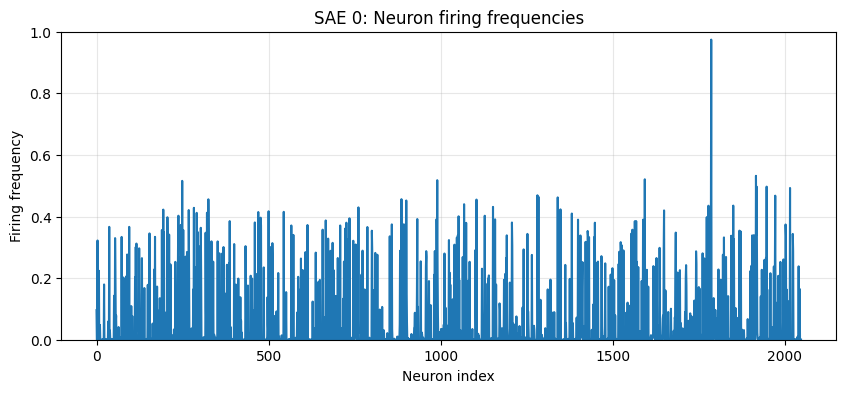


=== SAE 1 ===


Computing firing frequencies:   0%|          | 0/174 [00:00<?, ?it/s]

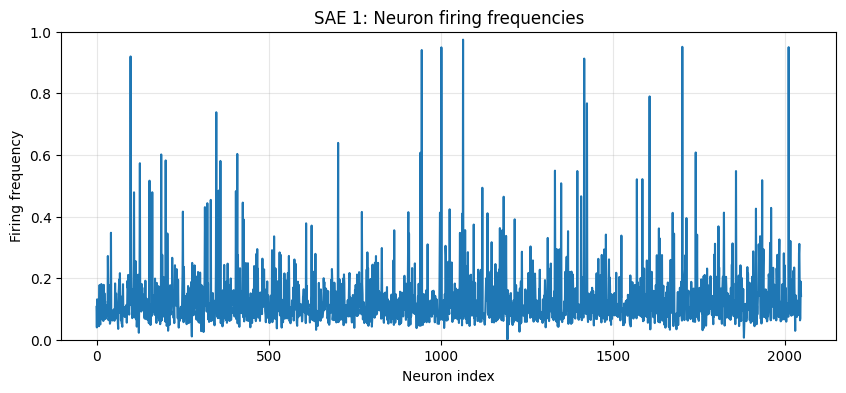


=== SAE 2 ===


Computing firing frequencies:   0%|          | 0/174 [00:00<?, ?it/s]

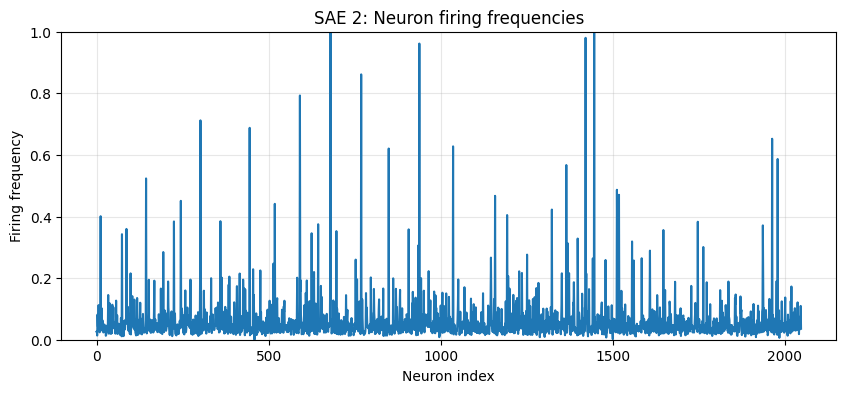


=== SAE 3 ===


Computing firing frequencies:   0%|          | 0/174 [00:00<?, ?it/s]

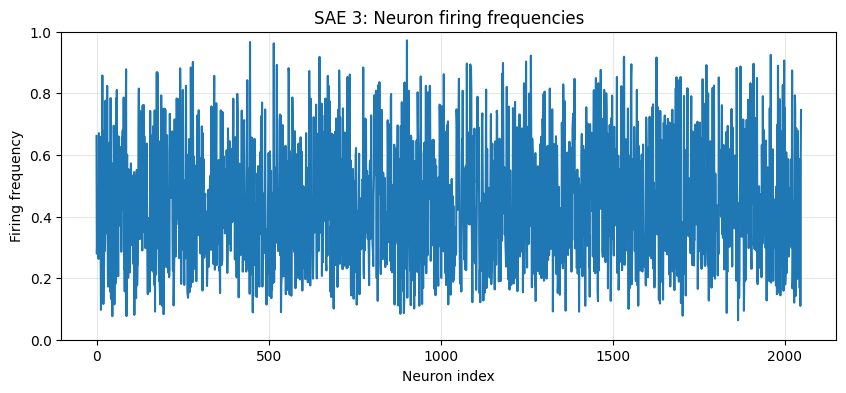

In [ ]:
for i, sae in enumerate(saes):
    print(f"\n=== SAE {i} ===")
    freq = compute_firing_frequencies(sae, data)
    plot_firing_frequencies(freq, i)


In [ ]:
# ============================================================
# Train Matryoshka SAEs on the collected activations
# ============================================================

# Your captured activations are already in:  data
# shape: [N_tokens, d_model]
def extract_activations(sample):
    acts_list = sample["activations"]

    # Concatenate across forward passes
    # Each tensor: [batch, seq, d_model]
    acts = torch.cat(acts_list, dim=1)   # [batch, total_seq, d_model]

    # Flatten batch + sequence
    acts = acts.reshape(-1, acts.shape[-1])

    return acts


import os

from google.colab import drive
drive.mount("/content/drive")
import os
import torch
import pandas as pd

# --------------------------------------------
# Paths (adjust if needed)
# --------------------------------------------
csv_path = "/content/drive/MyDrive/Pythia2.8B_reward_hacking_results.csv"
activation_dir = "/content/drive/MyDrive/SAE_Works_Pythia-2.8B/"

# --------------------------------------------
# Load CSV
# --------------------------------------------
df = pd.read_csv(csv_path)
print(df["reward_hacked"].dtype)
print(df["reward_hacked"].unique())
# Keep only reward-hacking examples
df_hacked = df[df["reward_hacked"] == False]


print(f"Using {len(df_hacked)} reward-hacking sequences")

# --------------------------------------------
# Load corresponding activation files
# --------------------------------------------
activation_tensors = []

for run_id, row in df.iterrows():
    if row["reward_hacked"]:
        continue

    filename = f"run_{run_id:05d}.pt"
    path = os.path.join(activation_dir, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing activation file: {path}")

    sample = torch.load(path)

    # sample["activations"] is a list of [1, seq, d_model] tensors
    acts_list = sample["activations"]

    # Concatenate across generation steps
    acts = torch.cat(acts_list, dim=1)   # [1, total_seq, d_model]

    # Flatten tokens
    acts = acts.reshape(-1, acts.shape[-1]).float()

    activation_tensors.append(acts)

print(f"Loaded {len(activation_tensors)} hacked activation files")




# --------------------------------------------
# Final SAE training tensor

# --------------------------------------------
data = torch.cat(activation_tensors, dim=0)

import pandas as pd

csv_path = "/content/drive/MyDrive/Pythia2.8B_reward_hacking_results.csv"
df = pd.read_csv(csv_path)

num_true = (df["reward_hacked"] == True).sum()
num_total = len(df)

print(f"Reward hacking TRUE: {num_true}")
print(f"Total samples: {num_total}")
print({num_true/num_total})
print(f"Fraction hacked: {num_true / num_total:.3f}")


print("Final SAE training data shape:", data.shape)



KeyboardInterrupt: 

In [ ]:
# ---- Hyperparameters ----
NUM_SAES = 4          # how many SAEs in the matryoshka stack
WIDTH = 2048          # hidden dimension for each SAE
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 3
device = "cuda" if torch.cuda.is_available() else "cpu"
d_in = data.shape[-1]
print("Activation tensor shape:", data.shape)
print("Training SAEs on device:", device)

# Matryoshka training loop (slightly upgraded for clarity)
saes = []
residual = data.clone()

for i in range(NUM_SAES):
    print(f"\n============================")
    print(f" TRAINING SAE {i+1}/{NUM_SAES}")
    print(f"============================")

    # Build dataset for this level
    dataset = torch.utils.data.TensorDataset(residual)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Create SAE
    sae_non_reward_hacked = SAE(d_in=d_in, d_hidden=WIDTH).to(device)

    # Train SAE
    opt_non_reward_hacked = torch.optim.AdamW(sae_non_reward_hacked.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        loop = tqdm(loader, desc=f"SAE {i+1} | Epoch {epoch+1}/{EPOCHS}")

        for (x,) in loop:
            x = x.to(device)
            x_hat, z = sae_non_reward_hacked(x)
            loss = sae_non_reward_hacked.loss(x, x_hat, z)

            opt_non_reward_hacked.zero_grad()
            loss.backward()
            opt_non_reward_hacked.step()

            loop.set_postfix(loss=f"{loss.item():.4f}")

        print(f"SAE {i+1} Epoch {epoch+1}: loss = {loss.item():.4f}")

    # Store trained SAE
    saes.append(sae_non_reward_hacked)

    # Compute residual for next SAE
    with torch.no_grad():
        x_hat, _ = sae_non_reward_hacked(residual.to(device))
        residual = (residual.to(device) - x_hat).cpu()

print("\n🎉 Finished training all Matryoshka SAEs!")
print(f"Total SAEs trained: {len(saes)}")


Activation tensor shape: torch.Size([370565, 2560])
Training SAEs on device: cuda

 TRAINING SAE 1/4


SAE 1 | Epoch 1/3:   0%|          | 0/1448 [00:00<?, ?it/s]

SAE 1 Epoch 1: loss = 0.0782


SAE 1 | Epoch 2/3:   0%|          | 0/1448 [00:00<?, ?it/s]

SAE 1 Epoch 2: loss = 0.0786


...

SAE 4 Epoch 1: loss = 0.4752


SAE 4 | Epoch 2/3:   0%|          | 0/1448 [00:00<?, ?it/s]

SAE 4 Epoch 2: loss = 0.2759


SAE 4 | Epoch 3/3:   0%|          | 0/1448 [00:00<?, ?it/s]

SAE 4 Epoch 3: loss = 0.2946

🎉 Finished training all Matryoshka SAEs!
Total SAEs trained: 4


In [ ]:
import os
import torch

# Define the directory to save the SAEs
save_dir = os.path.join(activation_dir, "layer 24")

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

print(f"Saving SAEs to: {save_dir}")

# Save each trained SAE
for i, sae_model in enumerate(saes):
    filename = f"sae_mixed{i+1}.pt"
    filepath = os.path.join(save_dir, filename)
    torch.save(sae_model, filepath)
    print(f"Saved {filename}")

print("All SAEs saved successfully!")

Saving SAEs to: /content/drive/MyDrive/SAE_Works_Pythia-2.8B/layer 24
Saved sae_mixed1.pt
Saved sae_mixed2.pt
Saved sae_mixed3.pt
Saved sae_mixed4.pt
All SAEs saved successfully!


In [ ]:
import torch
import os

# Create some dummy data
sample_data = torch.randn(10, 5)

# Define a path in your Google Drive
save_path = "/content/drive/MyDrive/my_sample_data.pt"

# Save the data
torch.save(sample_data, save_path)

print(f"Sample data saved to: {save_path}")

Sample data saved to: /content/drive/MyDrive/my_sample_data.pt


In [ ]:
import torch

# Define the path where the data was saved
load_path = "/content/drive/MyDrive/my_sample_data.pt"

# Load the data
loaded_data = torch.load(load_path)

print(f"Loaded data shape: {loaded_data.shape}")
print(f"Loaded data (first 3 rows):\n{loaded_data[:3]}")

Loaded data shape: torch.Size([10, 5])
Loaded data (first 3 rows):
tensor([[-0.1470, -1.9126,  1.0549,  0.2329, -0.5212],
        [ 0.7158, -2.4394, -0.1365, -0.8800,  0.9524],
        [-0.9250, -0.1633, -0.2498,  0.1800,  0.5265]])


In [ ]:
import torch
import os

# Define the path to save the 'data' tensor
# Using the previously defined activation_dir
save_path_data = os.path.join(activation_dir, "combined_activations.pt")

# Save the 'data' tensor
torch.save(data, save_path_data)

print(f"The 'data' variable has been saved to: {save_path_data}")

The 'data' variable has been saved to: /content/drive/MyDrive/SAE_Works_Pythia-2.8B/combined_activations.pt


In [ ]:
import os
import torch

base_dir = "/content/drive/MyDrive/SAE_Checkpoints/Pythia-2.8B/layer_24"
os.makedirs(base_dir, exist_ok=True)

for i, sae in enumerate(saes):
    ckpt = {
        "state_dict": sae.state_dict(),
        "config": {
            "d_in": sae.encoder.in_features,
            "d_hidden": sae.encoder.out_features,
            "l1_coeff": sae.l1_coeff,
            "sae_idx": i,
            "layer": 24,
            "model": "pythia-2.8b-deduped",
            "trained_on": "reward + clean"
        }
    }

    path = os.path.join(base_dir, f"sae_{i:02d}.pt")
    torch.save(ckpt, path)

    print(f"✓ Saved SAE {i} → {path}")


✓ Saved SAE 0 → /content/drive/MyDrive/SAE_Checkpoints/Pythia-2.8B/layer_24/sae_00.pt
✓ Saved SAE 1 → /content/drive/MyDrive/SAE_Checkpoints/Pythia-2.8B/layer_24/sae_01.pt
✓ Saved SAE 2 → /content/drive/MyDrive/SAE_Checkpoints/Pythia-2.8B/layer_24/sae_02.pt
✓ Saved SAE 3 → /content/drive/MyDrive/SAE_Checkpoints/Pythia-2.8B/layer_24/sae_03.pt


In [ ]:
# ============================================================
# Train Matryoshka SAEs on the collected activations
# ============================================================
#data mixed
# Your captured activations are already in:  data
# shape:w [N_tokens, d_model]
def extract_activations(sample):
    acts_list = sample["activations"]

    # Concatenate across forward passes
    # Each tensor: [batch, seq, d_model]
    acts = torch.cat(acts_list, dim=1)   # [batch, total_seq, d_model]

    # Flatten batch + sequence
    acts = acts.reshape(-1, acts.shape[-1])

    return acts


import os

from google.colab import drive
drive.mount("/content/drive")
import os
import torch
import pandas as pd

# --------------------------------------------
# Paths (adjust if needed)
# --------------------------------------------
csv_path = "/content/drive/MyDrive/Pythia2.8B_reward_hacking_results.csv"
activation_dir = "/content/drive/MyDrive/SAE_Works_Pythia-2.8B/"

# --------------------------------------------
# Load CSV
# --------------------------------------------
df = pd.read_csv(csv_path)
print(df["reward_hacked"].dtype)
print(df["reward_hacked"].unique())
# Keep only reward-hacking examples
df_hacked = df[df["reward_hacked"] == False]


print(f"Using {len(df_hacked)} reward-hacking sequences")

# --------------------------------------------
# Load corresponding activation files
# --------------------------------------------
activation_tensors = []

for run_id, row in df.iterrows():
    '''if row["reward_hacked"]:
        continue'''

    filename = f"run_{run_id:05d}.pt"
    path = os.path.join(activation_dir, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing activation file: {path}")

    sample = torch.load(path)

    # sample["activations"] is a list of [1, seq, d_model] tensors
    acts_list = sample["activations"]

    # Concatenate across generation steps
    acts = torch.cat(acts_list, dim=1)   # [1, total_seq, d_model]

    # Flatten tokens
    acts = acts.reshape(-1, acts.shape[-1]).float()

    activation_tensors.append(acts)

print(f"Loaded {len(activation_tensors)} hacked activation files")




# --------------------------------------------
# Final SAE training tensor

# --------------------------------------------
data = torch.cat(activation_tensors, dim=0)

import pandas as pd

csv_path = "/content/drive/MyDrive/Pythia2.8B_reward_hacking_results.csv"
df = pd.read_csv(csv_path)

num_true = (df["reward_hacked"] == True).sum()
num_total = len(df)

print(f"Reward hacking TRUE: {num_true}")
print(f"Total samples: {num_total}")
print({num_true/num_total})
print(f"Fraction hacked: {num_true / num_total:.3f}")


print("Final SAE training data shape:", data.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
bool
[ True False]
Using 1580 reward-hacking sequences
Loaded 2985 hacked activation files
Reward hacking TRUE: 1405
Total samples: 2985
{np.float64(0.47068676716917923)}
Fraction hacked: 0.471
Final SAE training data shape: torch.Size([370565, 2560])
